In [2]:
%load_ext autoreload
%autoreload 2

import json
from dfir_copilot.ingest.ingestor import ingest_csv

manifest = ingest_csv("/workspace/data/raw/three_months.csv", source="web_access_meli")
print(json.dumps(manifest, indent=2, ensure_ascii=False))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{
  "manifest_version": 1,
  "source": "web_access_meli",
  "ingested_at_utc": "2026-10-04T22:15:44+00:00",
  "duckdb_version": "1.5.6",
  "input": {
    "path": "/workspace/data/raw/three_months.csv",
    "bytes": 1180816975,
    "sha256": "128f5d7d57ce8ee30d2d22df2c6f43552963b55c44e3e560f6db8032aca9841a",
    "rows": 4478619
  },
  "output": {
    "path": "/workspace/data/processed/three_months.parquet",
    "bytes": 73338000,
    "sha256": "fa7a62e40f6b66d3d4f5201c9ead695f5a9a94625ec69cbb6bab55f598006795",
    "rows": 4478619
  },
  "mapping": {
    "path": "/workspace/src/dfir_copilot/ingest/mappings/web_access_meli.yaml",
    "sha256": "89b9c6c898dfeb889f500f92e1c7d685ad6491539bfa0c7163a352a626c69792"
  },
  "timezone": {
    "assumed": "UTC",
    "verified": false
  },
  "time_range_utc": [
    "2020-10-01 00:00:00+00",
    "2020-12-31 23:59:00+00"
  ],
  "null_counts": {
    "source_row": 0,


In [3]:
import duckdb

con = duckdb.connect()
con.execute("SET TimeZone = 'UTC'")
P = "/workspace/data/processed/three_months.parquet"

print("== 1) Primeras 3 filas (comparar con el `head` del CSV) ==")
display(con.sql(f"""
    SELECT source_row, timestamp_raw, CAST(timestamp_utc AS VARCHAR) AS timestamp_utc,
           status_code, src_ip, user_id, x_token_type, x_invoice_id, x_site_id
    FROM read_parquet('{P}') WHERE source_row <= 3 ORDER BY source_row
""").df())

print("== 2) Filas por mes ==")
display(con.sql(f"""
    SELECT strftime(timestamp_utc, '%Y-%m') AS mes, count(*) AS n
    FROM read_parquet('{P}') GROUP BY 1 ORDER BY 1
""").df())

print("== 3) Tipos de token ==")
display(con.sql(f"""
    SELECT x_token_type, count(*) AS n, count(DISTINCT user_id) AS usuarios
    FROM read_parquet('{P}') GROUP BY 1 ORDER BY n DESC
""").df())

== 1) Primeras 3 filas (comparar con el `head` del CSV) ==


,source_row,timestamp_raw,timestamp_utc,status_code,src_ip,user_id,x_token_type,x_invoice_id,x_site_id
0,1,2020-01-12T00:16,2020-12-01 00:16:00+00,201,27.0.2.178,jaxsonbuyer,ATUSER,229933235,MeliMX
1,2,2020-01-12T00:32,2020-12-01 00:32:00+00,200,27.0.2.110,ambrosebuyer,ATUSER,118825298,MeliAR
2,3,2020-01-12T00:11,2020-12-01 00:11:00+00,400,27.0.3.167,toolsuser,ATUSER,118824252,MeliCO


== 2) Filas por mes ==


,mes,n
0,2020-10,1787088
1,2020-11,1498320
2,2020-12,1193211


== 3) Tipos de token ==


,x_token_type,n,usuarios
0,ATUSER,4045921,32
1,TEST,432698,3


In [4]:
RAW = "/workspace/data/raw/three_months.csv"
display(con.sql(f"""
    SELECT substr("timestamp", 9, 2) AS mes_texto, count(*) AS n
    FROM read_csv('{RAW}', header=true, all_varchar=true)
    GROUP BY 1 ORDER BY 1
""").df())

,mes_texto,n
0,10,1787088
1,11,1498320
2,12,1193211


Días con más tráfico:


,dia,n
0,2020-10-01,57648
1,2020-10-02,57648
2,2020-10-03,57648
3,2020-10-04,57648
4,2020-10-05,57648


Días con menos tráfico:


,dia,n
62,2020-12-02,38448
63,2020-12-03,38448
61,2020-12-01,38448
76,2020-12-16,38448
75,2020-12-15,38448


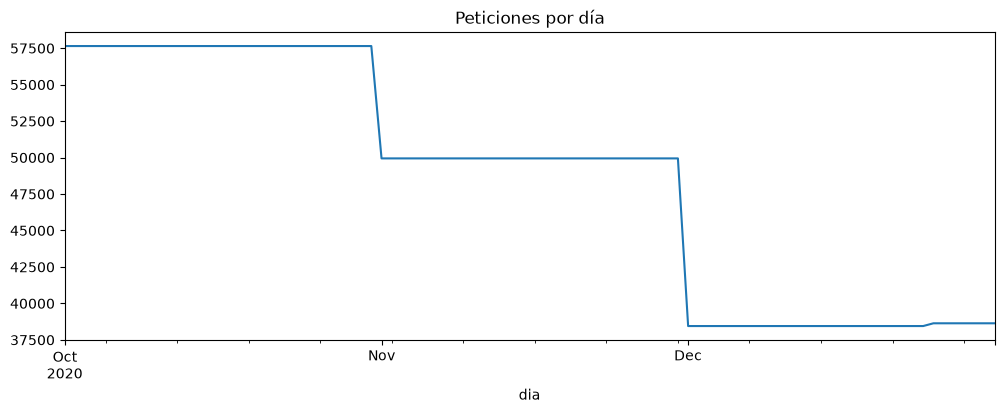

In [5]:
import pandas as pd

daily = con.sql(f"""
    SELECT CAST(CAST(timestamp_utc AS DATE) AS TIMESTAMP) AS dia, count(*) AS n
    FROM read_parquet('{P}') GROUP BY 1 ORDER BY 1
""").df()
daily["dia"] = pd.to_datetime(daily["dia"])

daily.plot(x="dia", y="n", figsize=(12, 4), legend=False, title="Peticiones por día")
print("Días con más tráfico:");  display(daily.sort_values("n", ascending=False).head(5))
print("Días con menos tráfico:"); display(daily.sort_values("n").head(5))

Días con más tráfico:


,dia,n
0,2020-10-01,57648
1,2020-10-02,57648
2,2020-10-03,57648
3,2020-10-04,57648
4,2020-10-05,57648


Días con menos tráfico:


,dia,n
62,2020-12-02,38448
63,2020-12-03,38448
61,2020-12-01,38448
76,2020-12-16,38448
75,2020-12-15,38448


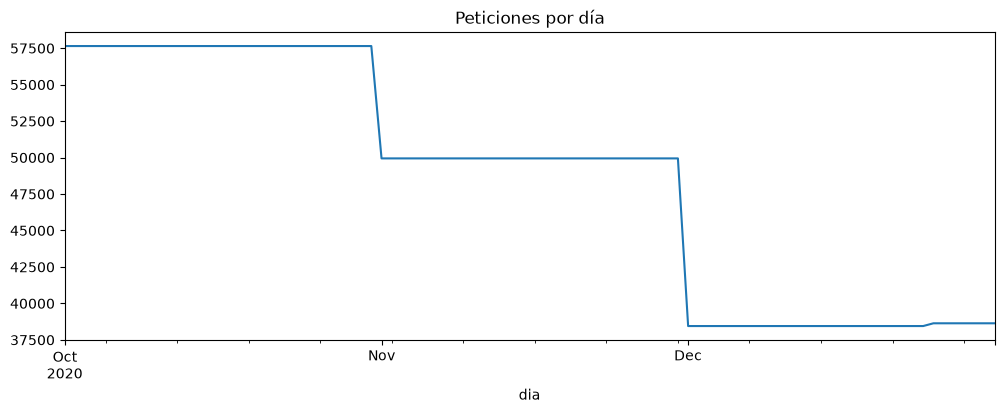

In [6]:
import pandas as pd

daily = con.sql(f"""
    SELECT CAST(CAST(timestamp_utc AS DATE) AS TIMESTAMP) AS dia, count(*) AS n
    FROM read_parquet('{P}') GROUP BY 1 ORDER BY 1
""").df()
daily["dia"] = pd.to_datetime(daily["dia"])

daily.plot(x="dia", y="n", figsize=(12, 4), legend=False, title="Peticiones por día")
print("Días con más tráfico:");  display(daily.sort_values("n", ascending=False).head(5))
print("Días con menos tráfico:"); display(daily.sort_values("n").head(5))